In [1]:
import tensorflow as tf
import numpy as np
import glob
import xarray as xr
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats

%reload_ext autoreload
%autoreload 2

# Configure environment
tf.get_logger().setLevel('ERROR')
TF_ENABLE_ONEDNN_OPTS = 0

2026-07-05 19:27:16.857993: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-05 19:27:16.858083: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-05 19:27:16.874663: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-05 19:27:16.924491: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-05 19:27:20.839421: W tensorflow/comp

In [2]:
# Function to compute weighted spatial averages
def weighted_spatial(data_array, lats):
    weights = np.cos(np.deg2rad(lats))
    weighted_data_array = np.multiply(data_array, weights[:, np.newaxis])
    weighted_sum = np.nansum(weighted_data_array.reshape(-1), axis=0)
    denom = np.nansum(weights) * 144
    return np.divide(weighted_sum, denom)


# Function to load data
def get_data(paths):
    X_MAPS = []
    Y_DATA = []
    model_names = []
    for path in paths:
        model_names.append(path.split('/')[9][:-3])

        # Load data
        ds = xr.open_dataset(path)
        ds_sel = ds.sel(period=slice(1900, 2050))

        # Get SAT & SLP or SLP data
        if SAT_SLP:
            X_maps_sat = ds_sel.X_SAT_SLP[:, :, :, :, :, 0]
            X_maps_slp = ds_sel.X_SAT_SLP[:, :, :, :, :, 1]
            X_maps = [X_maps_sat, X_maps_slp]
            X_maps = np.moveaxis(X_maps, 0, -1)
        else:
            X_maps = np.array(ds_sel.X_SAT_SLP[:, :, :, :, :, 1])  # SLP!!

        Y_data = np.array(ds_sel.Y_I_E_SUM)

        # Append to all paths
        X_MAPS.append(X_maps)
        Y_DATA.append(Y_data)

        ds.close()
    return X_MAPS, Y_DATA, model_names


# Observations actual trend computation
def compute_actual_trends(obs_maps):
    lats = np.arange(-88.75, 88.751, 2.5)

    actual_trends_all_obs = []
    for SAT in range(4):
        actual_trends_one_obs = []
        for SLP in range(3):
            actual_trends = []
            for month in range(12):
                actual_trends.append(weighted_spatial(obs_maps[SAT, SLP, month, 20:, :, 0], lats[64:]))
            actual_trends_one_obs.append(actual_trends)
        actual_trends_all_obs.append(actual_trends_one_obs)

    actual_trends_obs_means = np.nanmean(actual_trends_all_obs, axis=1)

    return actual_trends_obs_means, obs_maps


def create_CNN(input_shape):
    inpt = layers.Input(shape=input_shape)

    # Convolutional layer
    conv = layers.Conv2D(16, (1, 3), padding='same', activation='relu')(inpt)
    pool = layers.MaxPooling2D(1)(conv)
    drop = layers.Dropout(0.5)(pool)

    # Flatten and output layer
    flat = layers.Flatten()(drop)
    out = layers.Dense(2)(flat)

    model = models.Model(inputs=inpt, outputs=out)
    model.compile(loss='mse', optimizer=optimizers.Adam(learning_rate=1e-4))
    return model


def prepare_data(splice_X, splice_Y, hist_X, hist_Y, cv):
    # Bootstrap 10 ensemble members to train on from models with more than 10 members
    splice_X_10ens = []
    splice_Y_10ens = []
    for idx in range(len(splice_X)):
        random_idxs = tf.random.shuffle(tf.range(tf.shape(splice_X[idx])[0]))[:10]

        # ---------- EDIT ----------
        splice_X_10ens.append(tf.gather(splice_X[idx][:, :, 2], random_idxs))                        # March SAT and SLP
        # splice_X_10ens.append(tf.gather(splice_X[idx][:, :, 3], random_idxs))                        # April SAT and SLP
        # splice_X_10ens.append(tf.gather(np.nanmean(splice_X[idx][:, :, 2:4], axis=2), random_idxs))  # March-April Mean SAT and SLP
        # splice_X_10ens.append(tf.gather(splice_X[idx][:, :, 2:4], random_idxs))                      # March and April SAT and SLP
        # splice_X_10ens.append(tf.gather(np.stack((splice_X[idx][:, :, 2, :, :, 0], splice_X[idx][:, :, 3, :, :, 1]), axis=-1), random_idxs))  # March SLP and April SAT

        splice_Y_10ens.append(tf.gather(splice_Y[idx][:, :, 2], random_idxs))

    hist_X_10ens = []
    hist_Y_10ens = []
    for idx in range(len(hist_X)):
        random_idxs = tf.random.shuffle(tf.range(tf.shape(hist_X[idx])[0]))[:10]

        # ---------- EDIT ----------
        hist_X_10ens.append(tf.gather(hist_X[idx][:, :, 2], random_idxs))                        # March SAT and SLP
        # hist_X_10ens.append(tf.gather(hist_X[idx][:, :, 3], random_idxs))                        # April SAT and SLP
        # hist_X_10ens.append(tf.gather(np.nanmean(hist_X[idx][:, :, 2:4], axis=2), random_idxs))  # March-April Mean SAT and SLP
        # hist_X_10ens.append(tf.gather(hist_X[idx][:, :, 2:4], random_idxs))                      # March and April SAT and SLP
        # hist_X_10ens.append(tf.gather(np.stack((hist_X[idx][:, :, 2, :, :, 0], hist_X[idx][:, :, 3, :, :, 1]), axis=-1), random_idxs))  # March SLP and April SAT

        hist_Y_10ens.append(tf.gather(hist_Y[idx][:, :, 2], random_idxs))

    # Delete the specified index for E3SM-2-0
    if no_E3SM:
        if cv == 0:
            X_train_spliced = tf.concat([splice_X_10ens[i] for i in range(tf.shape(splice_X_10ens)[0])], axis=0)
            Y_train_spliced = tf.concat([splice_Y_10ens[i] for i in range(tf.shape(splice_Y_10ens)[0])], axis=0)
        else:
            X_train_spliced = tf.concat([splice_X_10ens[i] for i in range(tf.shape(splice_X_10ens)[0]) if i != cv], axis=0)
            Y_train_spliced = tf.concat([splice_Y_10ens[i] for i in range(tf.shape(splice_Y_10ens)[0]) if i != cv], axis=0)
    else:
        X_train_spliced = tf.concat([splice_X_10ens[i] for i in range(tf.shape(splice_X_10ens)[0]) if i != cv], axis=0)
        Y_train_spliced = tf.concat([splice_Y_10ens[i] for i in range(tf.shape(splice_Y_10ens)[0]) if i != cv], axis=0)

    # Concatenate the hist tensors
    X_train_hist = tf.concat(hist_X_10ens, axis=0)
    Y_train_hist = tf.concat(hist_Y_10ens, axis=0)

    # Reshape to put ensembles and time periods in same axis
    # new_shape_spliced = (-1, *X_train_spliced.shape[2:])
    # X_train_spliced = tf.reshape(X_train_spliced, new_shape_spliced)

    # new_shape_hist = (-1, *X_train_hist.shape[2:])
    # X_train_hist = tf.reshape(X_train_hist, new_shape_hist)

    X_train_spliced = tf.reshape(X_train_spliced, (-1, X_train_spliced.shape[2], X_train_spliced.shape[3], X_train_spliced.shape[4]))
    X_train_hist = tf.reshape(X_train_hist, (-1, X_train_hist.shape[2], X_train_hist.shape[3], X_train_hist.shape[4]))

    Y_train_spliced = tf.reshape(Y_train_spliced, (-1, Y_train_spliced.shape[2]))
    Y_train_hist = tf.reshape(Y_train_hist, (-1, Y_train_hist.shape[2]))

    # Concatenate and reshape training data
    X_train = tf.concat([X_train_spliced, X_train_hist], axis=0)
    Y_train = tf.concat([Y_train_spliced, Y_train_hist], axis=0)
    return X_train, Y_train

In [3]:
# 1. Parameter count
model = create_CNN(input_shape=(28, 144, 2))
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 144, 2)]      0         
                                                                 
 conv2d (Conv2D)             (None, 28, 144, 16)       112       
                                                                 
 max_pooling2d (MaxPooling2  (None, 28, 144, 16)       0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 28, 144, 16)       0         
                                                                 
 flatten (Flatten)           (None, 64512)             0         
                                                                 
 dense (Dense)               (None, 2)                 129026    
                                                             

2026-07-05 19:27:28.763836: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


NameError: name 'model_names_spliced' is not defined

In [17]:
# Main
region = 'Arctic'
SAT_SLP = False
no_E3SM = True

In [18]:
# Load observation data
sat_paths = np.sort(glob.glob('/pscratch/sd/s/skygale/training-data/monthly/observations/sat/*.nc'))[::-1]
slp_paths = glob.glob('/pscratch/sd/s/skygale/training-data/monthly/observations/slp/*')

obs_maps = []
for sat_path in sat_paths:
    print(sat_path)
    ds_sat = xr.load_dataset(sat_path)
    X_maps_sat = ds_sat.DATA[:, 44:]

    for slp_path in slp_paths:
        ds_slp = xr.load_dataset(slp_path)
        X_maps_slp = ds_slp.DATA[:, 44:]
        obs_maps.append(np.stack([X_maps_sat, X_maps_slp], axis=-1))

obs_maps = np.reshape(obs_maps, (4, 3, 12, 28, 144, 2))
actual_trends_obs_means, obs_maps = compute_actual_trends(obs_maps)
obs_maps = np.reshape(obs_maps, (12, 12, 28, 144, 2))
actual_trends_obs_means.shape, obs_maps.shape

/pscratch/sd/s/skygale/training-data/monthly/observations/sat/NOAAv6.nc
/pscratch/sd/s/skygale/training-data/monthly/observations/sat/HadCRUTv5.nc
/pscratch/sd/s/skygale/training-data/monthly/observations/sat/GISTv4.nc
/pscratch/sd/s/skygale/training-data/monthly/observations/sat/BerkeleyEarth.nc


((4, 12), (12, 12, 28, 144, 2))

In [14]:
# Define paths to spliced and historical files
spliced_path = '/pscratch/sd/s/skygale/training-data/monthly/spliced/'
hist_path = '/pscratch/sd/s/skygale/training-data/monthly/hist/'
spliced = glob.glob(spliced_path+region.lower()+'/*')
hist = glob.glob(hist_path+region.lower()+'/*')

# Remove unwanted files
spliced = [model for model in spliced if 'OthersAllEM.nc' not in model]
hist = [model for model in hist if 'OthersAllEM.nc' not in model]

# Store data
splice_X, splice_Y, model_names_spliced_old = get_data(spliced)
hist_X, hist_Y, model_names_hist = get_data(hist)

# Reorganize models by warming indices
models_reorganized = ['E3SM-2-0', 'CanESM5', 'MIROC6', 'MPI-ESM1-2-LR', 'IPSL-CM6A-LR', 'ACCESS-ESM1-5', 'CESM2', 'CESM2_SMBB']
ranked_warming_indices = [model_names_spliced_old.index(name) for name in models_reorganized]
splice_X_array = [splice_X[i] for i in ranked_warming_indices]
splice_Y_array = [splice_Y[i] for i in ranked_warming_indices]
model_names_spliced = [model_names_spliced_old[i] for i in ranked_warming_indices]

# Convert observations into PyTorch tensors
splice_X = []
[splice_X.append(tf.convert_to_tensor(splice_X_array[i])) for i in range(len(splice_X_array))]
splice_Y = []
[splice_Y.append(tf.convert_to_tensor(splice_Y_array[i])) for i in range(len(splice_Y_array))]
obs_maps = tf.convert_to_tensor(obs_maps)

print('Observations | Monthly Means:', np.round(np.nanmean(actual_trends_obs_means, axis=0), 3))
print('CMIP6 Models | Type:', type(splice_X[0]))

MPI-ESM1-2-LR
MIROC6
CESM2
IPSL-CM6A-LR
ACCESS-ESM1-5
CanESM5
CESM2_SMBB
E3SM-2-0
MPI-ESM1-2-HR
GISS-E2-1-H
NorCPM1
GISS-E2-1-G


I0000 00:00:1753732525.105674  301250 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38366 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


Observations | Monthly Means: [0.957 0.801 0.797 1.004 0.558 0.373 0.32  0.445 0.653 1.203 1.311 1.071]
CMIP6 Models | Type: <class 'tensorflow.python.framework.ops.EagerTensor'>


In [15]:
for i, splice in enumerate(splice_X):
    print(i+1, np.shape(splice), model_names_spliced[i])
print('\n')
for i, splice in enumerate(splice_Y):
    print(i+1, np.shape(splice), model_names_spliced[i])
print('\n')

# Remove E3SMv2 from training data
if no_E3SM:
    splice_X_cut = splice_X[1:]
    splice_Y_cut = splice_Y[1:]
    model_names_spliced_cut = model_names_spliced[1:]

    for i, splice in enumerate(splice_X_cut):
        print(i+1, np.shape(splice), model_names_spliced_cut[i])
    print('\n')
    for i, splice in enumerate(splice_Y_cut):
        print(i+1, np.shape(splice), model_names_spliced_cut[i])
    print('\nE3SM not included in training data.')
else:
    print('E3SM included in training data.')

1 (21, 22, 12, 28, 144, 2) E3SM-2-0
2 (25, 22, 12, 28, 144, 2) CanESM5
3 (50, 22, 12, 28, 144, 2) MIROC6
4 (10, 22, 12, 28, 144, 2) MPI-ESM1-2-LR
5 (11, 22, 12, 28, 144, 2) IPSL-CM6A-LR
6 (25, 22, 12, 28, 144, 2) ACCESS-ESM1-5
7 (50, 22, 12, 28, 144, 2) CESM2
8 (50, 22, 12, 28, 144, 2) CESM2_SMBB


1 (21, 22, 12, 3) E3SM-2-0
2 (25, 22, 12, 3) CanESM5
3 (50, 22, 12, 3) MIROC6
4 (10, 22, 12, 3) MPI-ESM1-2-LR
5 (11, 22, 12, 3) IPSL-CM6A-LR
6 (25, 22, 12, 3) ACCESS-ESM1-5
7 (50, 22, 12, 3) CESM2
8 (50, 22, 12, 3) CESM2_SMBB


1 (25, 22, 12, 28, 144, 2) CanESM5
2 (50, 22, 12, 28, 144, 2) MIROC6
3 (10, 22, 12, 28, 144, 2) MPI-ESM1-2-LR
4 (11, 22, 12, 28, 144, 2) IPSL-CM6A-LR
5 (25, 22, 12, 28, 144, 2) ACCESS-ESM1-5
6 (50, 22, 12, 28, 144, 2) CESM2
7 (50, 22, 12, 28, 144, 2) CESM2_SMBB


1 (25, 22, 12, 3) CanESM5
2 (50, 22, 12, 3) MIROC6
3 (10, 22, 12, 3) MPI-ESM1-2-LR
4 (11, 22, 12, 3) IPSL-CM6A-LR
5 (25, 22, 12, 3) ACCESS-ESM1-5
6 (50, 22, 12, 3) CESM2
7 (50, 22, 12, 3) CESM2_SMBB

E3SM not

In [11]:
# Create arrays for which to store result
cv_preds_and_vals = []
cv_obs = []
cv_mse = []
prediction_error = []

# Main training loop
Xscale = MinMaxScaler()
Yscale = MinMaxScaler()

with tf.device('/GPU:0'):

    # Loop through each large ensemble we test on
    for cv in range(len(splice_X)):
        print('Cross Validation:', model_names_spliced[cv])

        cv_preds_and_vals_one_randomization = []
        cv_obs_one_randomization = []

        # Create the CNN 50 times to cut noise from random initializations
        for randomization in range(50):
            # Define training data
            X_train, Y_train = prepare_data(splice_X_cut, splice_Y_cut, hist_X, hist_Y, cv)

            # Reshape training data for CNN
            X_train_reshaped = tf.reshape(X_train, (tf.shape(X_train)[0], -1))
            Y_train_reshaped = Y_train[:, :2]

            # Define testing data
            # ---------- EDIT ----------
            X_test = splice_X[cv][:, -6, 2]                        # March SAT and SLP
            # X_test = splice_X[cv][:, -6, 3]                        # April SAT and SLP
            # X_test = np.nanmean(splice_X[cv][:, -6, 2:4], axis=1)  # March-April Mean SAT and SLP
            # X_test = splice_X[cv][:, -6, 2:4]                      # March and April SAT and SLP
            # X_test = np.stack((splice_X[cv][:, -6, 2, :, :, 0], splice_X[cv][:, -6, 2, :, :, 1]), axis=-1)  # March SLP and April SAT

            X_test_reshaped = tf.reshape(X_test, (tf.shape(X_test)[0], -1))
            Y_test_reshaped = splice_Y[cv][:, -6, 2, :2]

            # Scale training and testing data
            Xscale.fit(X_train_reshaped.numpy())
            Yscale.fit(Y_train_reshaped.numpy())
            X_train_scaled = Xscale.transform(X_train_reshaped.numpy())
            X_test_scaled = Xscale.transform(X_test_reshaped.numpy())
            Y_train_scaled = Yscale.transform(Y_train_reshaped.numpy())

            # Put data back into sample x map x channel shape
            if SAT_SLP:
                X_train_scaled = tf.reshape(X_train_scaled, tf.shape(X_train))
                X_test_scaled = tf.reshape(X_test_scaled, tf.shape(X_test))
            else:
                X_train_scaled = tf.reshape(X_train_scaled, (tf.shape(X_train)[0], tf.shape(X_train)[1], tf.shape(X_train)[2], 1))
                X_test_scaled = tf.reshape(X_test_scaled, (tf.shape(X_test)[0], tf.shape(X_test)[1], tf.shape(X_test)[2], 1))

            '''
            shape = tf.shape(X_train_scaled)
            new_shape = (-1, shape[2], shape[3], shape[1] * shape[4])
            X_train_scaled = tf.reshape(X_train_scaled, new_shape)
            X_test_scaled = tf.reshape(X_test_scaled, new_shape)
            '''

            # Create the model
            model = create_CNN(input_shape=X_train_scaled.shape[1:])

            # Fit the model with validation data
            model.fit(X_train_scaled, Y_train_scaled,
                      epochs=10,
                      verbose=0,
                      batch_size=32,
                      shuffle=True)

            # Make predictions on testing data
            Y_pred_scaled = model.predict(X_test_scaled)
            Y_preds_unscaled = Yscale.inverse_transform(Y_pred_scaled)

            # Reshape prediction and actual values
            Y_pred = tf.transpose(Y_preds_unscaled).numpy().tolist()
            Y_test_one_model = tf.transpose(Y_test_reshaped).numpy().tolist()

            # Append sum values to prediction and actual values
            Y_pred.append(np.nansum(Y_pred, axis=0))
            Y_test_one_model.append(np.nansum(Y_test_one_model, axis=0))
            cv_preds_and_vals_one_randomization.append([tf.transpose(Y_pred), tf.transpose(Y_test_one_model)])

            # Prepare predicting data
            # ---------- EDIT ----------
            obs_map = obs_maps[:, 2]                        # March SAT and SLP
            # obs_map = obs_maps[:, 3]                        # April SAT and SLP
            # obs_map = np.nanmean(obs_maps[:, 2:4], axis=1)  # March-April Mean SAT and SLP
            # obs_map = obs_maps[:, 2:4]                      # March and April SAT and SLP
            # obs_map = np.stack((obs_maps[:, 2, :, :, 0], obs_maps[:, 3, :, :, 1]), axis=-1)  # March SLP and April SAT

            X_obs_reshaped = tf.reshape(obs_map, (tf.shape(obs_map)[0], -1))

            # Make predictions on observations
            X_obs_scaled = Xscale.transform(X_obs_reshaped.numpy())
            X_obs_map_scaled = tf.reshape(X_obs_scaled, tf.shape(obs_map))
            # X_obs_map_scaled = tf.reshape(X_obs_map_scaled, new_shape)
            obs_Y_pred_scaled = model.predict(X_obs_map_scaled)

            # Reshape observation prediction values
            obs_Y_pred_unscaled = Yscale.inverse_transform(obs_Y_pred_scaled)
            Y_obs = tf.transpose(obs_Y_pred_unscaled).numpy().tolist()
            Y_obs.append(np.nansum(Y_obs, axis=0))
            cv_obs_one_randomization.append(Y_obs)

        # Find mean prediction for the current cross-validation fold
        mean_of_randomizations_val = tf.reduce_mean(cv_preds_and_vals_one_randomization, axis=0).numpy()
        mean_of_randomizations_obs = tf.reduce_mean(cv_obs_one_randomization, axis=0).numpy()
        error = mean_of_randomizations_val[0] - mean_of_randomizations_val[1]
        prediction_error.append(error)
        mse_of_cv = [tf.reduce_mean(tf.square(error[:, i])).numpy() for i in range(3)]

        # Append to arrays of all cvs
        cv_preds_and_vals.append(mean_of_randomizations_val)
        cv_obs.append(mean_of_randomizations_obs)
        cv_mse.append(mse_of_cv)

# Save values
for i in range(len(model_names_spliced)):
    np.save('./preds_and_vals/mar_pred_mar/'+region.lower()+'_'+str(model_names_spliced[i])+'.npy', np.array(cv_preds_and_vals[i]))
np.save('./preds_and_vals/mar_pred_mar/'+region+'_obs.npy', np.array(cv_obs))

print('Done!')

Cross Validation: E3SM-2-0


2025-05-10 13:59:58.462940: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:116] None of the MLIR optimization passes are enabled (registered 2)
2025-05-10 13:59:58.480329: I tensorflow/core/platform/profile_utils/cpu_utils.cc:112] CPU Frequency: 2600000000 Hz
2025-05-10 13:59:59.135088: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcublas.so.10
2025-05-10 13:59:59.925033: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudnn.so.7


Cross Validation: CanESM5
Cross Validation: MIROC6
Cross Validation: MPI-ESM1-2-LR
Cross Validation: IPSL-CM6A-LR
Cross Validation: ACCESS-ESM1-5
Cross Validation: CESM2
Cross Validation: CESM2_SMBB
Done!


Sigma_obs: 0.0309387
Sigma_CNN: 0.20922115
Sigma_obs: 0.042513706
Sigma_CNN: 0.20253274
Sigma_obs: 0.05558961
Sigma_CNN: 0.03626955


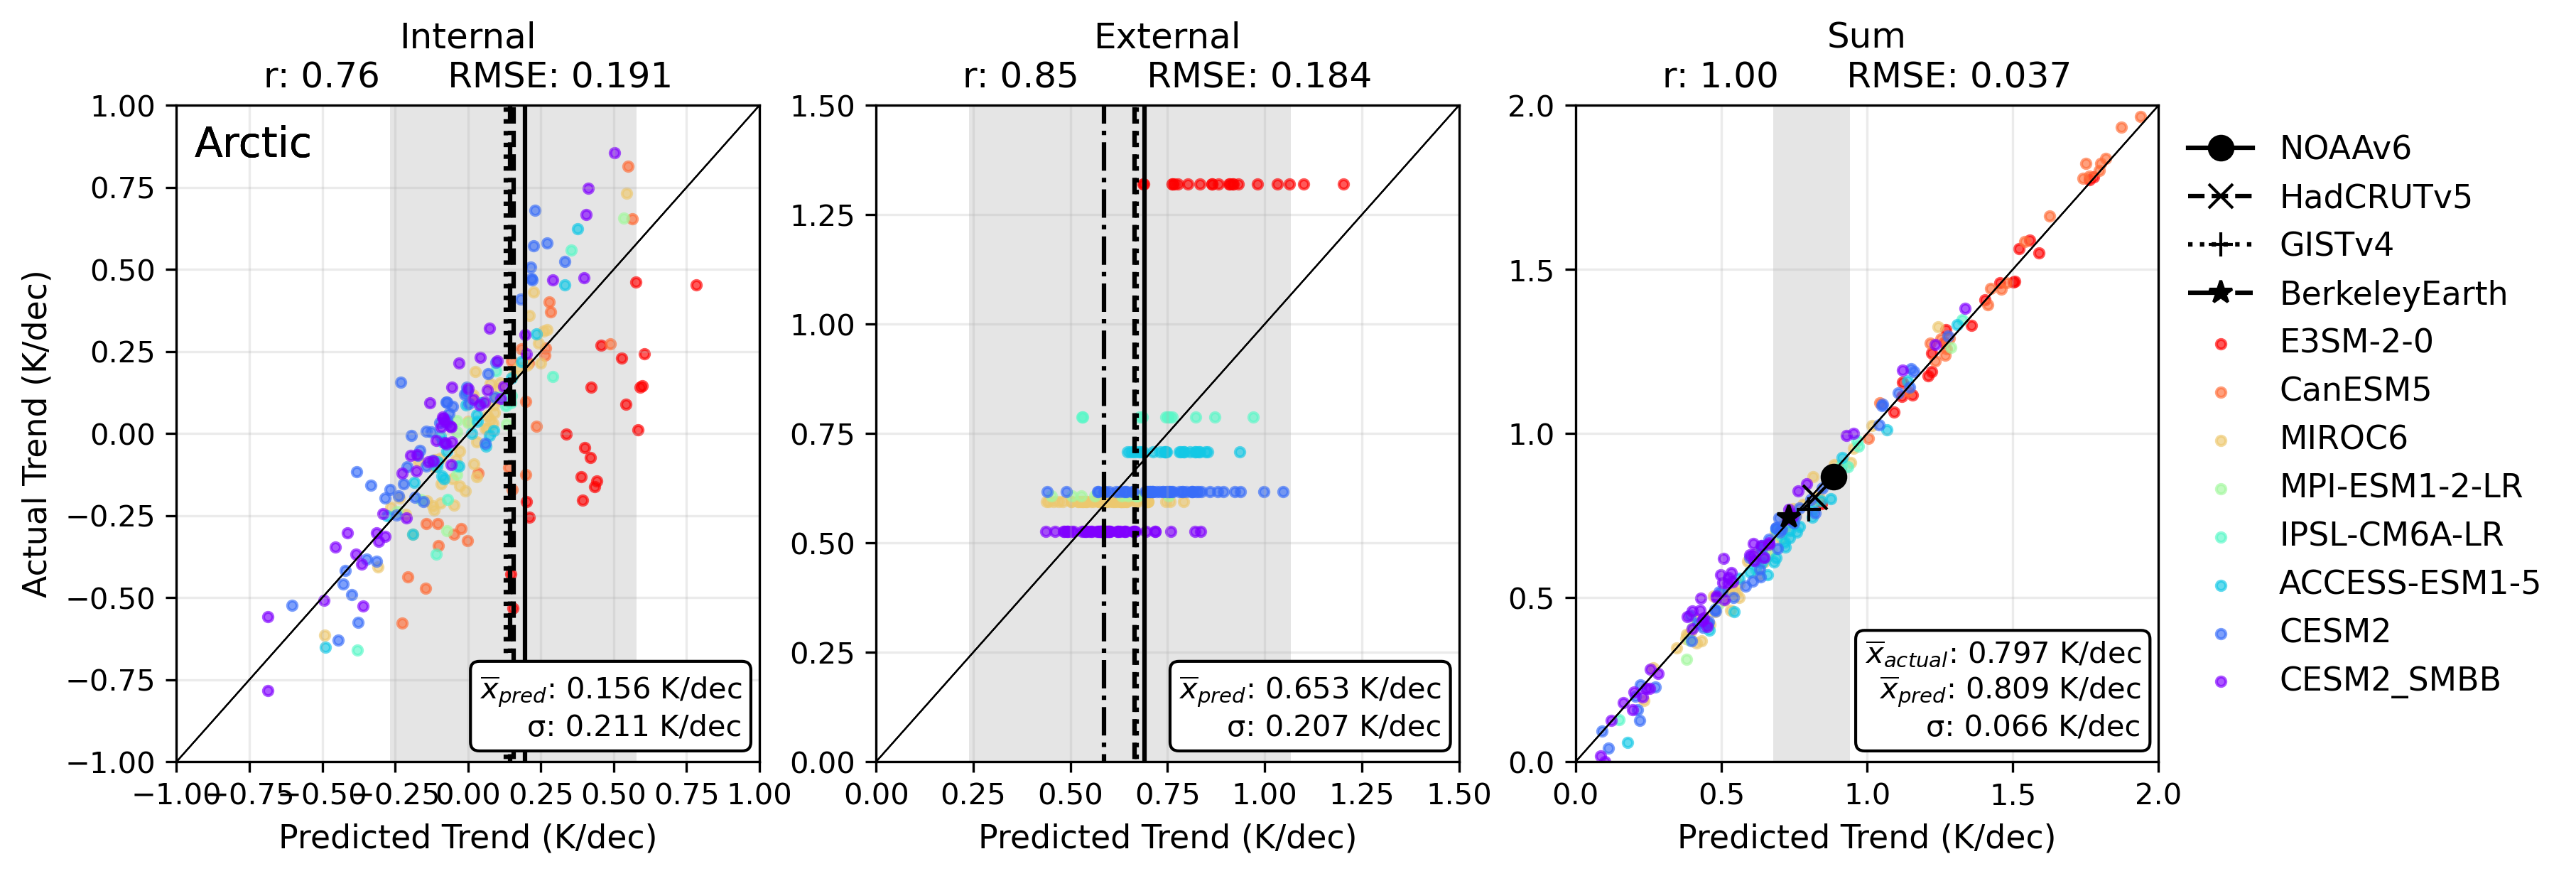

In [15]:
titles = ['Internal', 'External', 'Sum']
obs_labels = ['NOAAv6', 'HadCRUTv5', 'GISTv4', 'BerkeleyEarth']
obs_markers = ['o', 'x', '+', '*']
linestyles = ['-', '--', ':', '-.']
colors = cm.rainbow(np.linspace(0, 1, 8))[::-1]
bbox = dict(facecolor='white', ec='black', boxstyle='round')
ticks = np.arange(-1, 1.01, 0.25),  np.arange(0, 1.51, 0.25), np.arange(0, 2.1, 0.5)
top = 0.1

obs_actual = str(np.round(np.nanmean(actual_trends_obs_means, axis=0), 3)[2])

fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=300, facecolor='white')
cv_preds_and_vals_ = cv_preds_and_vals
cv_obs_ = np.swapaxes(np.array(cv_obs), 0, 2)

new_errors = []
for error in prediction_error:
    squared_error = np.multiply(error, error)
    new_errors.append(squared_error/len(squared_error))
new_errors_all = np.concatenate(new_errors)
new_errors_sum = np.nansum(new_errors_all, 0)
new_errors_std = np.sqrt(new_errors_sum/8)

for i in range(3):
    axs[0].text(0.03, 0.97, f'{region}', fontsize=14, transform=axs[0].transAxes, va='top', ha='left')
    all_obs_spread = np.nanmean(cv_obs_[:, i, :], 1).ravel()
    obs_mean = np.nanmean(all_obs_spread)
    sigma_obs = np.nanstd(all_obs_spread)
    sigma_cnn = new_errors_std[i]
    print('Sigma_obs:', sigma_obs)
    print('Sigma_CNN:', sigma_cnn)
    sigma = np.sqrt(sigma_obs**2+sigma_cnn**2)
    axs[i].axvspan(obs_mean-2*sigma, obs_mean+2*sigma, color='grey', alpha=0.2, ec=None)
    cv_obs_set = cv_obs_[:, i, :].reshape(4, 3, 8)
    mean = str(round(obs_mean, 3))
    std = str(round(sigma, 3))

    if i in [0, 1]:
        text = '$\overline{x}$$_{pred}$: '+mean+' K/dec\nσ: '+std+' K/dec'
        axs[i].text(0.97, 0.03, text, transform=axs[i].transAxes, fontsize=10, va='bottom', ha='right', bbox=bbox)
        for idx in range(len(cv_obs_set)):
            obs_set_all_cv = cv_obs_set[idx]
            mean_obs = np.nanmean(obs_set_all_cv)
            axs[i].plot(np.repeat(mean_obs, 3), [-5, 0.3, 5], linestyle=linestyles[idx], linewidth=1.5, color='k', label=obs_labels[idx])
    else:
        text = '$\overline{x}$$_{actual}$: '+obs_actual+' K/dec'+'\n$\overline{x}$$_{pred}$: '+mean+' K/dec\nσ: '+std+' K/dec'
        axs[i].text(0.97, 0.03, text, transform=axs[i].transAxes, fontsize=10,  va='bottom', ha='right', bbox=bbox)
        for idx in range(len(cv_obs_set)):
            obs_set_all_cv = cv_obs_set[idx]
            mean_obs = np.nanmean(obs_set_all_cv)
            axs[i].plot(mean_obs, actual_trends_obs_means[:, 2][idx], linestyle=linestyles[idx], marker=obs_markers[idx], markersize=8, color='k', label=obs_labels[idx])

for model_idx, set_of_preds_and_vals in enumerate(cv_preds_and_vals_):
    Y_pred = np.array(set_of_preds_and_vals[0])
    Y_test = np.array(set_of_preds_and_vals[1])

    for i in range(3):
        axs[i].scatter(Y_pred[:, i], Y_test[:, i], color=colors[model_idx], s=10, alpha=0.65, label=model_names_spliced[model_idx])
        axs[i].axline((0, 0), slope=1, color='k', alpha=0.5, linewidth=0.5)
        axs[i].set_xticks(ticks[i])
        axs[i].set_yticks(ticks[i])
        axs[i].set_ylim(ticks[i][0], ticks[i][-1])
        axs[i].set_xlim(ticks[i][0], ticks[i][-1])

all_preds_and_vals = np.concatenate(cv_preds_and_vals_, axis=1)
labels = ['A', 'B', 'C']

for i in range(3):
    Y_pred = all_preds_and_vals[0]
    Y_test = all_preds_and_vals[1]
    MSE = np.nanmean(np.square(Y_pred[:, i]-Y_test[:, i]), 0)
    MSE_str = str(np.around(MSE, 5))
    r = stats.pearsonr(Y_pred[:, i], Y_test[:, i])[0]
    r_str = str(np.around(r, 3))
    axs[i].set_title(titles[i]+'\nr: {:.2f}'.format(round(r, 2))+'      RMSE: {:.3f}'.format(round(np.sqrt(MSE), 3)), fontsize=12)
    axs[i].set_xlabel('Predicted Trend (K/dec)', fontsize=11)
    axs[0].set_ylabel('Actual Trend (K/dec)', fontsize=11)
    axs[i].grid(alpha=0.25)
    axs[i].tick_params(axis='both', which='major', labelsize=10)
    axs[i].tick_params(axis='both', which='minor', labelsize=10)

axs[2].legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=11)
plt.show()